# 데이터 업로드

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving open.zip to open.zip


In [ ]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

os.listdir("/content/data")

['train', 'sample_submission.csv', 'test']

In [ ]:
os.listdir("/content/data/train")

['meta', 'train.csv']

In [ ]:
os.listdir("/content/data/test")

['TEST_01.csv',
 'TEST_00.csv',
 'TEST_21.csv',
 'TEST_14.csv',
 'TEST_09.csv',
 'meta',
 'TEST_18.csv',
 'TEST_10.csv',
 'TEST_04.csv',
 'TEST_06.csv',
 'TEST_19.csv',
 'TEST_22.csv',
 'TEST_17.csv',
 'TEST_23.csv',
 'TEST_24.csv',
 'TEST_02.csv',
 'TEST_11.csv',
 'TEST_16.csv',
 'TEST_12.csv',
 'TEST_05.csv',
 'TEST_15.csv',
 'TEST_13.csv',
 'TEST_08.csv',
 'TEST_20.csv',
 'TEST_07.csv',
 'TEST_03.csv']

In [ ]:
import pandas as pd
import glob

train = pd.read_csv("/content/data/train/train.csv")
files = glob.glob("/content/data/test/TEST_*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

test = pd.concat(dfs, ignore_index=True)

train.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0
3,201802상순,건고추,화건,30 kg,상품,380000.000000,590000.0
4,201802중순,건고추,화건,30 kg,상품,376666.666667,590000.0


In [ ]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29376 entries, 0 to 29375
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   시점          29376 non-null  object 
 1   품목명         29376 non-null  object 
 2   품종명         29376 non-null  object 
 3   거래단위        29376 non-null  object 
 4   등급          29376 non-null  object 
 5   평년 평균가격(원)  29376 non-null  float64
 6   평균가격(원)     29376 non-null  float64
dtypes: float64(2), object(5)
memory usage: 1.6+ MB


,평년 평균가격(원),평균가격(원)
count,2.937600e+04,2.937600e+04
mean,1.772730e+04,5.224625e+04
std,1.521004e+05,4.545482e+05
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,1.055214e+03
75%,5.203333e+02,1.289481e+04
max,5.213802e+06,1.335000e+07


In [ ]:
test.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,T-8순,건고추,화건,30 kg,상품,592768.000000,578819.0
1,T-7순,건고추,화건,30 kg,상품,0.000000,579167.0
2,T-6순,건고추,화건,30 kg,상품,637704.333333,539583.0
3,T-5순,건고추,화건,30 kg,상품,635516.666667,597600.0
4,T-4순,건고추,화건,30 kg,상품,637272.333333,671225.0


In [ ]:
print(train.shape)
print(test.shape)
print(train.columns)

(29376, 7)
(45900, 7)
Index(['시점', '품목명', '품종명', '거래단위', '등급', '평년 평균가격(원)', '평균가격(원)'], dtype='object')


# 결측치/이상치 확인

In [ ]:
# null값 확인
print(train.isnull().sum())
print((train.isnull().sum() / len(train)) * 100)

시점            0
품목명           0
품종명           0
거래단위          0
등급            0
평년 평균가격(원)    0
평균가격(원)       0
dtype: int64
시점            0.0
품목명           0.0
품종명           0.0
거래단위          0.0
등급            0.0
평년 평균가격(원)    0.0
평균가격(원)       0.0
dtype: float64


In [ ]:
# 품목별 0 비율 확인
zero_ratio = train.groupby('품목명')['평균가격(원)'].apply(lambda x: (x==0).mean())
zero_ratio

,평균가격(원)
품목명,
감자,0.592172
건고추,0.480903
깐마늘(국산),0.000000
대파,0.314484
무,0.642887
배,0.454861
배추,0.130876
사과,0.554167
상추,0.000000


In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.3 MB/s eta 0:00:00


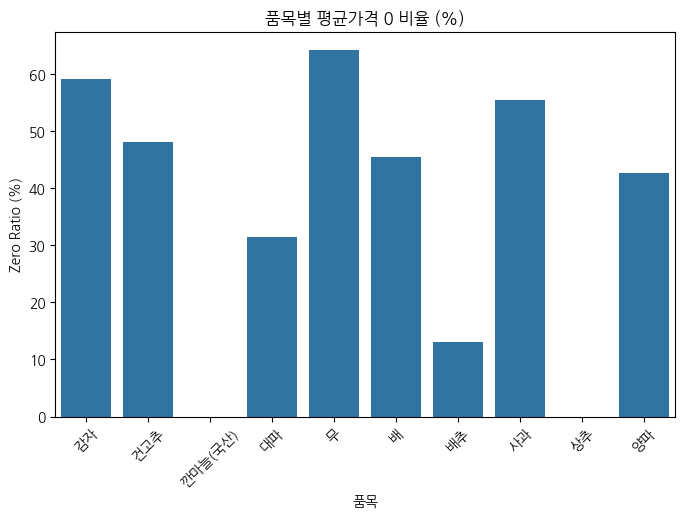

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=zero_ratio.index, y=zero_ratio.values*100)

plt.ylabel("Zero Ratio (%)")
plt.xlabel("품목")
plt.title("품목별 평균가격 0 비율 (%)")
plt.xticks(rotation=45)

plt.show()

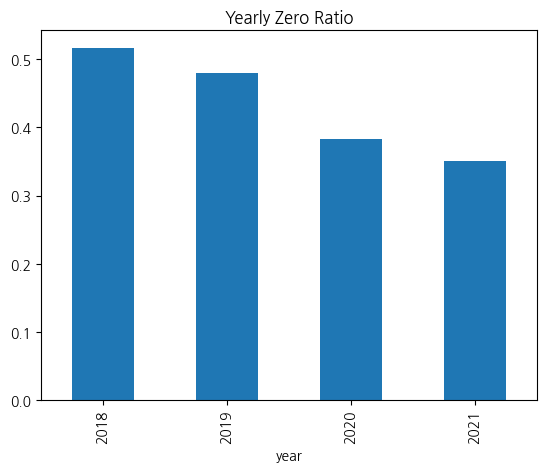

In [ ]:
#연도별 0 비율
train['year'] = train['시점'].str[:4]

year_zero = train.groupby('year')['평균가격(원)'].apply(lambda x:(x==0).mean())

year_zero.plot(kind='bar', title='Yearly Zero Ratio')
plt.show()

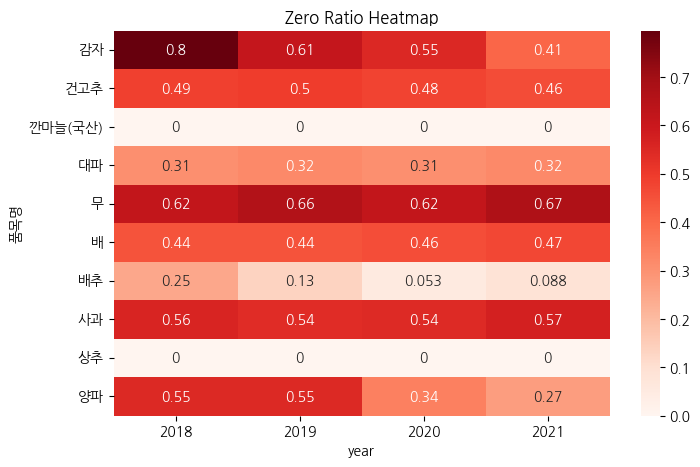

In [ ]:
#품종x연도 0 비율
pivot = train.pivot_table(
    index='품목명',
    columns='year',
    values='평균가격(원)',
    aggfunc=lambda x:(x==0).mean()
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Zero Ratio Heatmap")
plt.show()

감자 , 배추 ??

## 분포 확인

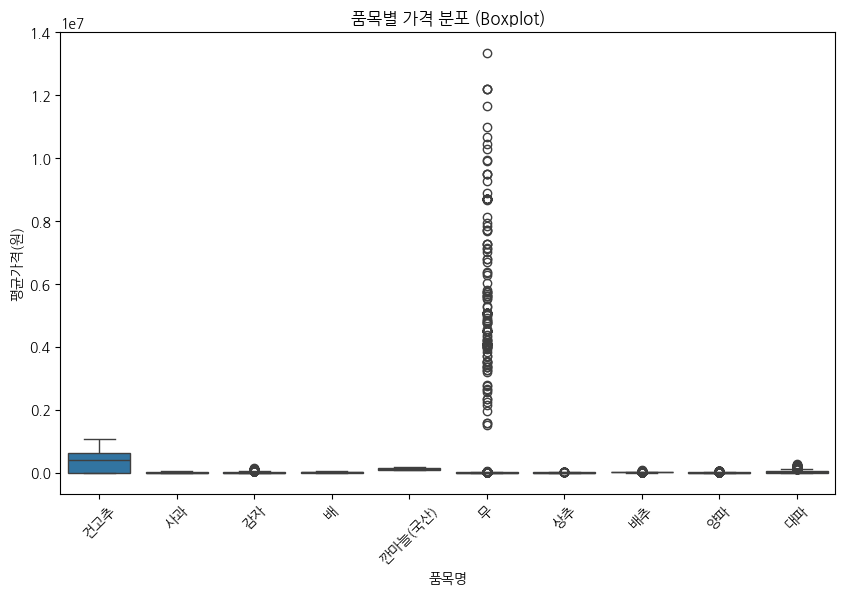

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=train, x='품목명', y='평균가격(원)')

plt.xticks(rotation=45)
plt.title("품목별 가격 분포 (Boxplot)")

plt.show()

In [ ]:
Q1 = train['평균가격(원)'].quantile(0.25)
Q3 = train['평균가격(원)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[(train['평균가격(원)'] < lower) | (train['평균가격(원)'] > upper)]

print("이상치 개수:", len(outliers))
print("비율:", len(outliers)/len(train))

이상치 개수: 2903
비율: 0.09882216775599129


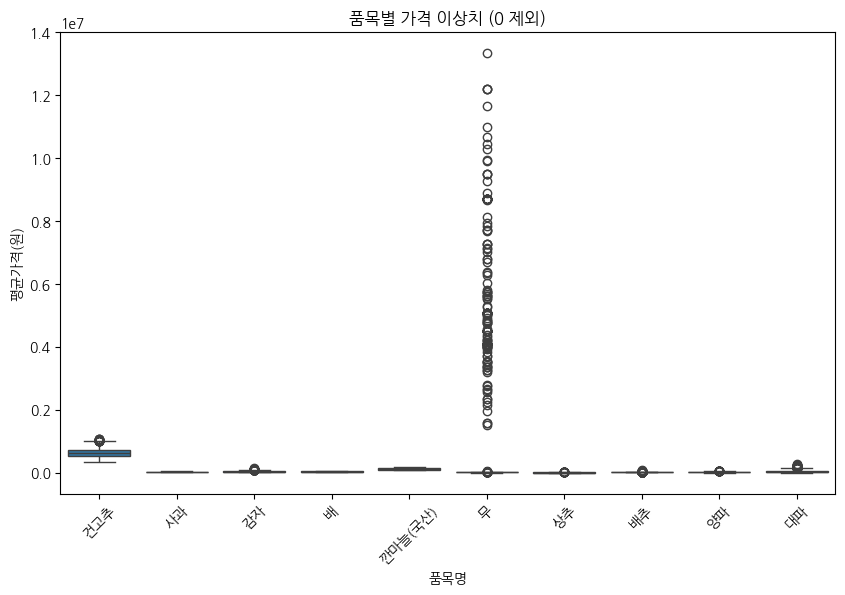

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=price_nonzero,
    x='품목명',
    y='평균가격(원)'
)

plt.xticks(rotation=45)
plt.title("품목별 가격 이상치 (0 제외)")

plt.show()

## 정리본

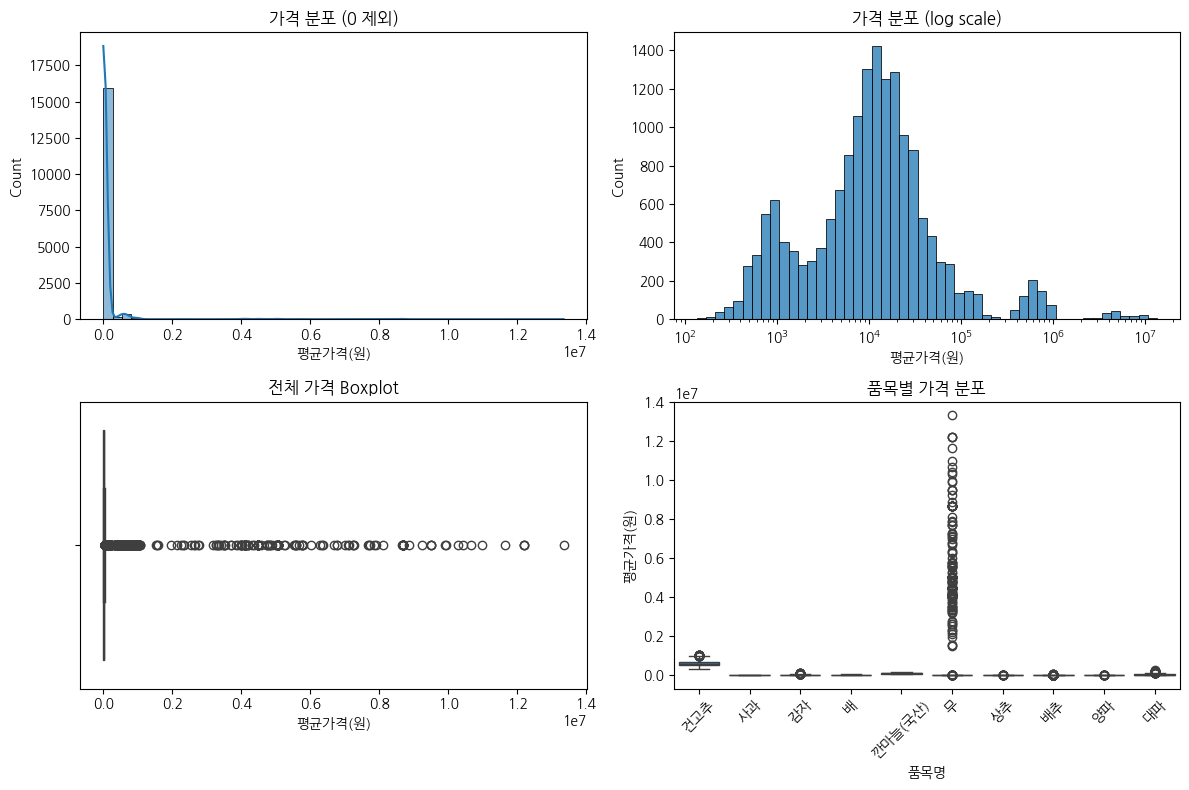

In [ ]:
# 0 제외 데이터
price_nonzero = train[train['평균가격(원)'] != 0]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# 1. 전체 가격 분포
sns.histplot(price_nonzero['평균가격(원)'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title("가격 분포 (0 제외)")
axes[0,0].set_xlabel("평균가격(원)")

# 2. log 스케일 가격 분포 (스케일 차이 확인)
sns.histplot(price_nonzero['평균가격(원)'], bins=50, log_scale=True, ax=axes[0,1])
axes[0,1].set_title("가격 분포 (log scale)")

# 3. 전체 이상치 확인
sns.boxplot(x=price_nonzero['평균가격(원)'], ax=axes[1,0])
axes[1,0].set_title("전체 가격 Boxplot")

# 4. 품목별 이상치
sns.boxplot(data=price_nonzero, x='품목명', y='평균가격(원)', ax=axes[1,1])
axes[1,1].set_title("품목별 가격 분포")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

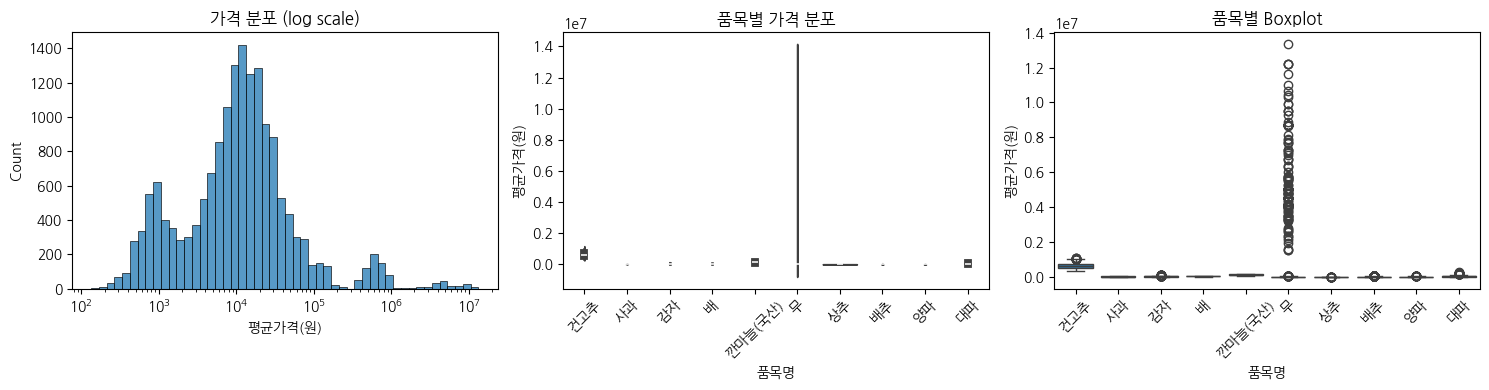

In [ ]:
# 0 제외 데이터
price_nonzero = train[train['평균가격(원)'] != 0]

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# 1. log scale 가격 분포
sns.histplot(price_nonzero['평균가격(원)'], bins=50, log_scale=True, ax=axes[0])
axes[0].set_title("가격 분포 (log scale)")
axes[0].set_xlabel("평균가격(원)")

# 2. 품목별 가격 분포 (violinplot)
sns.violinplot(data=price_nonzero, x='품목명', y='평균가격(원)', ax=axes[1])
axes[1].set_title("품목별 가격 분포")
axes[1].tick_params(axis='x', rotation=45)

# 3. 품목별 박스플롯
sns.boxplot(data=price_nonzero, x='품목명', y='평균가격(원)', ax=axes[2])
axes[2].set_title("품목별 Boxplot")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- 건고추 - 고가 품목
- 대부분 농산물 1,000원 ~ 10,000원

violinplot
- 가격 스케일 차이
- ex. 위쪽 두꺼움 -> 높은 가격대 많음 / 두 군데 두꺼움 -> 이중분포
- 품목별 가격 스케일 차이 큼 -> 품목별 모델...?

boxplot
- 건고추 이상치 많음 -> 가격 변동 큼

In [ ]:
# 이상치 비율 계산 (IQR)
Q1 = price_nonzero['평균가격(원)'].quantile(0.25)
Q3 = price_nonzero['평균가격(원)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = price_nonzero[(price_nonzero['평균가격(원)'] < lower) | (price_nonzero['평균가격(원)'] > upper)]

print("이상치 개수:", len(outliers))
print("이상치 비율:", len(outliers)/le품목-품종별

n(price_nonzero))

이상치 개수: 1817
이상치 비율: 0.1090439896777291


## 품목-품종

In [ ]:
train.groupby('품목명')['품종명'].nunique()

,품종명
품목명,
감자,9
건고추,4
깐마늘(국산),1
대파,5
무,3
배,2
배추,6
사과,3
상추,2


## 0 -> nan 변환

In [ ]:
train['평균가격(원)'] = train['평균가격(원)'].replace(0, None)
train['평년 평균가격(원)'] = train['평년 평균가격(원)'].replace(0, None)

In [ ]:
train.isnull().sum()

,0
시점,0
품목명,0
품종명,0
거래단위,0
등급,0
평년 평균가격(원),21860
평균가격(원),12713


In [ ]:
train['year'] = train['시점'].str[:4]
train['month'] = train['시점'].str[4:6]
train['순'] = train['시점'].str[6:]

# meta 데이터 비교

In [ ]:
import pandas as pd
import glob

# 1) 원본 train
train = pd.read_csv("/content/data/train/train.csv")

# 2) meta의 두 csv 읽기
meta_files = glob.glob("/content/data/train/meta/*.csv")
train2 = pd.read_csv(meta_files[0])
train3 = pd.read_csv(meta_files[1])

# 3) 기준 키
keys = ['시점', '품목명', '품종명']

# 4) train에서 평균가격이 0인 행
train_zero = train[train['평균가격(원)'] == 0].copy()

# 5) 보조 데이터에서 사용할 컬럼
aux_cols = [
    '전순 평균가격(원) PreVious SOON',
    '전달 평균가격(원) PreVious MMonth',
    '전년 평균가격(원) PreVious YeaR',
    '평년 평균가격(원) Common Year SOON'
]

# 6) 같은 시점/품목명/품종명 기준으로 집계
#    (시장 단위로 여러 행이 있을 수 있으니 평균으로 묶음)
aux2 = train2.groupby(keys)[aux_cols].mean().reset_index()
aux3 = train3.groupby(keys)[aux_cols].mean().reset_index()

# 7) merge
merged = (
    train_zero
    .merge(aux2, on=keys, how='left', suffixes=('', '_aux2'))
    .merge(aux3, on=keys, how='left', suffixes=('', '_aux3'))
)

# 8) 각 컬럼별로 "다른 csv에서 0이 아닌 값이 하나라도 있는지" 확인
for col in aux_cols:
    merged[f'{col}_fillable'] = (
        ((merged[col].notna()) & (merged[col] != 0)) |
        ((merged[f'{col}_aux3'].notna()) & (merged[f'{col}_aux3'] != 0))
    )

# 9) 하나라도 채울 수 있는 행
fillable_any = merged[[f'{col}_fillable' for col in aux_cols]].any(axis=1)

# 10) 전부 못 채우는 행
unfillable_all = ~fillable_any

print("train.csv에서 평균가격(원)=0 인 행 수:", len(train_zero))
print("보조 csv의 전순/전달/전년/평년 가격 중 하나라도 사용 가능한 행 수:", fillable_any.sum())
print("보조 csv에서도 전부 0 또는 결측인 행 수:", unfillable_all.sum())

print("\n컬럼별 fill 가능 행 수")
for col in aux_cols:
    print(f"{col}: {merged[f'{col}_fillable'].sum()}")

merged.head()

train.csv에서 평균가격(원)=0 인 행 수: 12713
보조 csv의 전순/전달/전년/평년 가격 중 하나라도 사용 가능한 행 수: 7002
보조 csv에서도 전부 0 또는 결측인 행 수: 5711

컬럼별 fill 가능 행 수
전순 평균가격(원) PreVious SOON: 6848
전달 평균가격(원) PreVious MMonth: 6764
전년 평균가격(원) PreVious YeaR: 6482
평년 평균가격(원) Common Year SOON: 4831


,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원),전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,전순 평균가격(원) PreVious SOON_aux3,전달 평균가격(원) PreVious MMonth_aux3,전년 평균가격(원) PreVious YeaR_aux3,평년 평균가격(원) Common Year SOON_aux3,전순 평균가격(원) PreVious SOON_fillable,전달 평균가격(원) PreVious MMonth_fillable,전년 평균가격(원) PreVious YeaR_fillable,평년 평균가격(원) Common Year SOON_fillable
0,201801상순,건고추,햇산양건,30 kg,상품,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False
1,201801중순,건고추,햇산양건,30 kg,상품,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False
2,201801하순,건고추,햇산양건,30 kg,상품,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False
3,201802상순,건고추,햇산양건,30 kg,상품,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False
4,201802중순,건고추,햇산양건,30 kg,상품,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False


# EDA(타겟만)

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

file_name = list(uploaded.keys())[0]
train_target = pd.read_csv(file_name)

print(train_target.shape)
train_target.head()

Saving train_target_only_cleaned.csv to train_target_only_cleaned.csv
(1425, 7)


,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0
3,201802상순,건고추,화건,30 kg,상품,380000.000000,590000.0
4,201802중순,건고추,화건,30 kg,상품,376666.666667,590000.0


In [ ]:
# 시점 분해
train_target['year'] = train_target['시점'].astype(str).str[:4].astype(int)
train_target['month'] = train_target['시점'].astype(str).str[4:6].astype(int)
train_target['순'] = train_target['시점'].astype(str).str[6:]

# 순서 매핑
soon_map = {'상순': 1, '중순': 2, '하순': 3}
train_target['순_num'] = train_target['순'].map(soon_map)

# 정렬용 시간 인덱스
train_target['time_order'] = (
    train_target['year'] * 100 + train_target['month'] * 10 + train_target['순_num']
)

# 정렬
train_target = train_target.sort_values(
    ['품목명', '품종명', 'time_order']
).reset_index(drop=True)

train_target.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원),year,month,순,순_num,time_order
0,201801상순,감자,감자 수미,20키로상자,상,24660.031746,44170.285714,2018,1,상순,1,201811
1,201801중순,감자,감자 수미,20키로상자,상,23299.444444,48283.777778,2018,1,중순,2,201812
2,201801하순,감자,감자 수미,20키로상자,상,25218.007407,50243.000000,2018,1,하순,3,201813
3,201802상순,감자,감자 수미,20키로상자,상,28703.875000,55380.666667,2018,2,상순,1,201821
4,201802중순,감자,감자 수미,20키로상자,상,27419.882275,59133.000000,2018,2,중순,2,201822


In [ ]:
print(train_target.isnull().sum())
print((train_target['평균가격(원)'] == 0).sum())

시점            0
품목명           0
품종명           0
거래단위          0
등급            0
평년 평균가격(원)    0
평균가격(원)       0
year          0
month         0
순             0
순_num         0
time_order    0
dtype: int64
0


## 시계열

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 48.4 MB/s eta 0:00:00


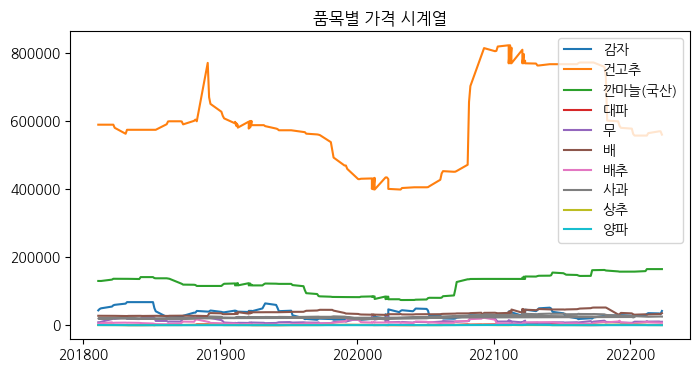

In [ ]:
#품목별 가격 시계열
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

for item in train_target['품목명'].unique():
    df = train_target[train_target['품목명'] == item]
    plt.plot(df['time_order'], df['평균가격(원)'], label=item)

plt.legend()
plt.title("품목별 가격 시계열")
plt.show()

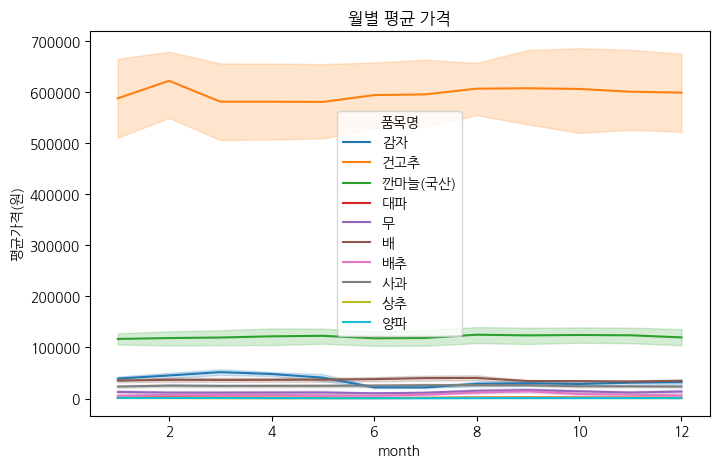

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data=train_target, x='month', y='평균가격(원)', hue='품목명', estimator='mean')
plt.title("월별 평균 가격")
plt.show()

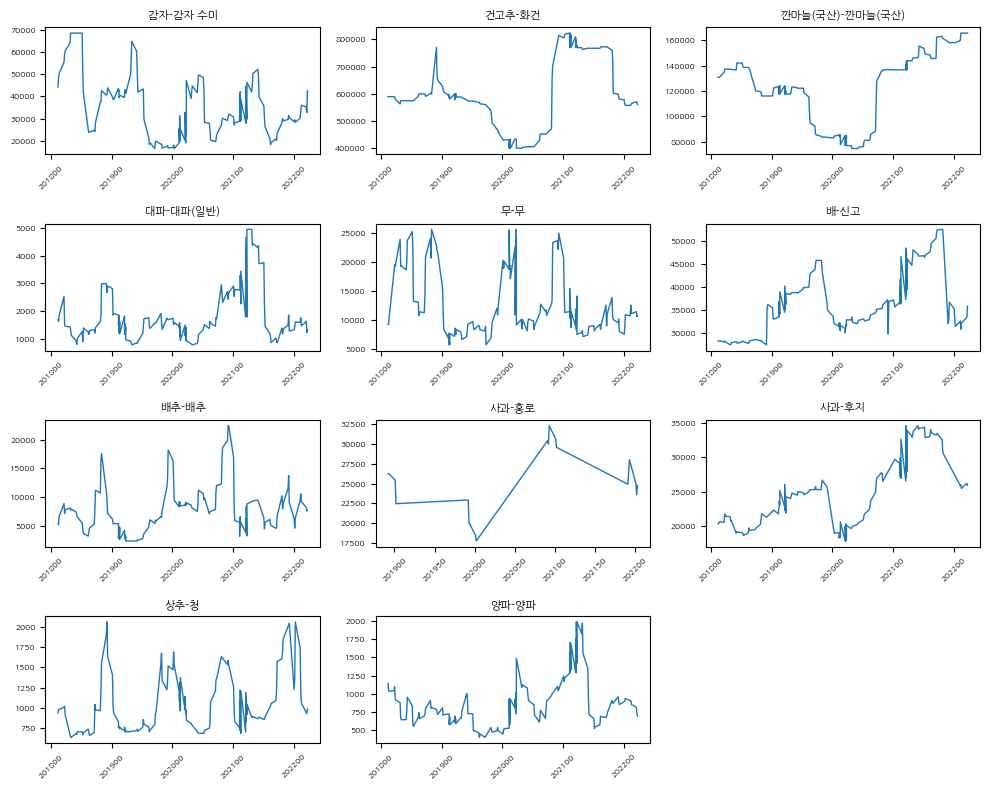

In [ ]:
import matplotlib.pyplot as plt

items = train_target[['품목명','품종명']].drop_duplicates().values

fig, axes = plt.subplots(4, 3, figsize=(10, 8))

for i, (item, variety) in enumerate(items):
    ax = axes[i//3, i%3]

    df = train_target[
        (train_target['품목명']==item) &
        (train_target['품종명']==variety)
    ]

    ax.plot(df['time_order'], df['평균가격(원)'], linewidth=1)
    ax.set_title(f"{item}-{variety}", fontsize=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6)

# 남는 subplot 제거
for j in range(len(items), 12):
    fig.delaxes(axes[j//3, j%3])

plt.tight_layout()
plt.show()

대부분 연속성 존재(사과-홍로 제외)

-> price(t) ≈ price(t-1)

-> lag 강함

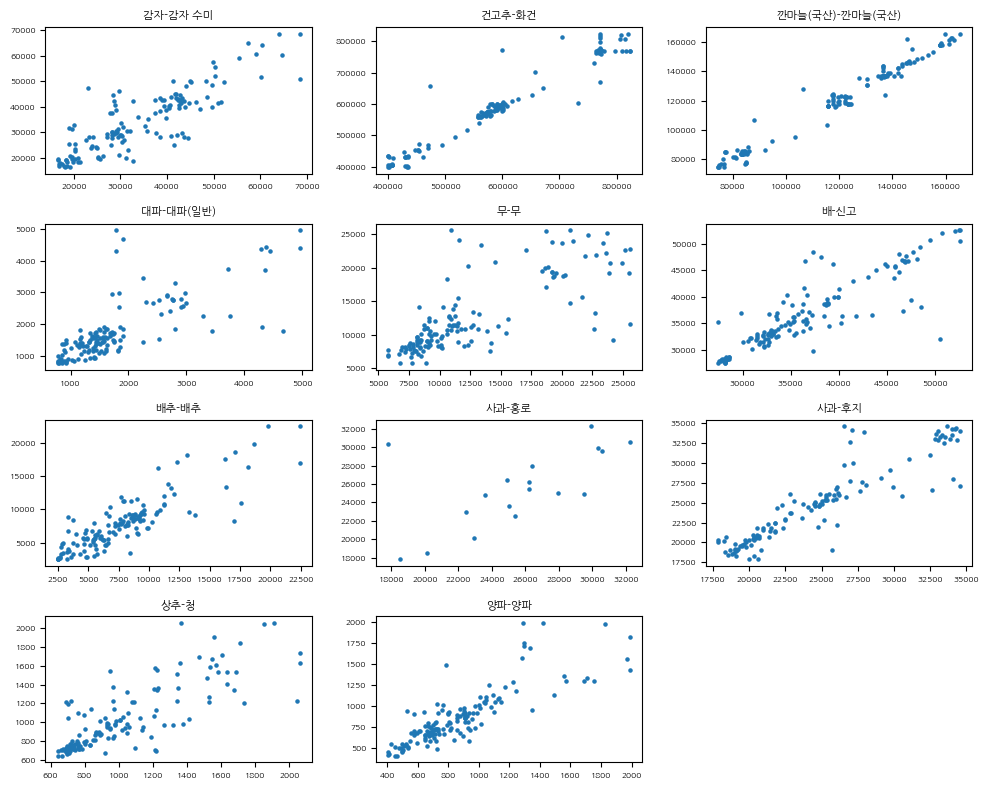

In [ ]:
#lag plot → "과거 가격이 미래 가격 설명하는 정도"
import matplotlib.pyplot as plt

items = train_target[['품목명','품종명']].drop_duplicates().values

fig, axes = plt.subplots(4, 3, figsize=(10, 8))

for i, (item, variety) in enumerate(items):
    ax = axes[i//3, i%3]

    df = train_target[
        (train_target['품목명']==item) &
        (train_target['품종명']==variety)
    ].sort_values('time_order')

    ax.scatter(df['평균가격(원)'].shift(1), df['평균가격(원)'], s=5)
    ax.set_title(f"{item}-{variety}", fontsize=8)
    ax.tick_params(labelsize=6)

for j in range(len(items), 12):
    fig.delaxes(axes[j//3, j%3])

plt.tight_layout()
plt.show()

x: price(t-1)

y: price(t)

- price(t) ≈ a * price(t-1)
- 대부분 선형 형태
- 과거 값으로 미래 값 예측 가능
- lag 피처 사용

+) diff(차분) 피처 추가 - 변화량 정보 추가

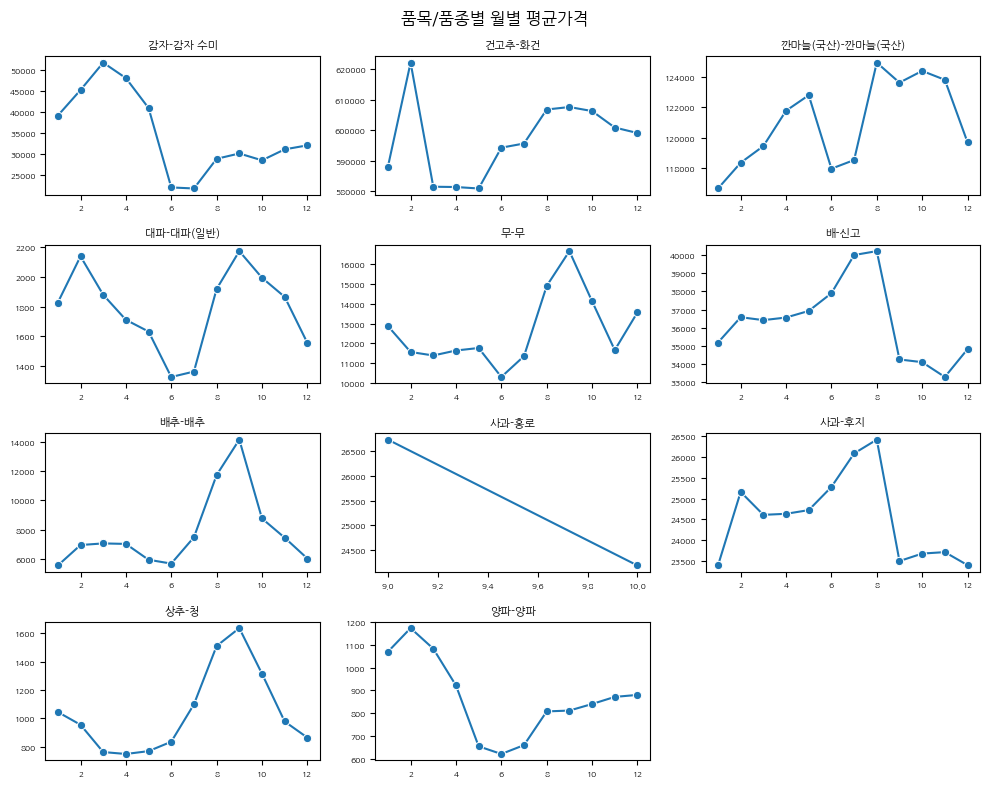

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

items = train_target[['품목명','품종명']].drop_duplicates().values

fig, axes = plt.subplots(4, 3, figsize=(10, 8))

for i, (item, variety) in enumerate(items):
    ax = axes[i//3, i%3]

    df = train_target[
        (train_target['품목명'] == item) &
        (train_target['품종명'] == variety)
    ]

    monthly = df.groupby('month', as_index=False)['평균가격(원)'].mean()

    sns.lineplot(data=monthly, x='month', y='평균가격(원)', marker='o', ax=ax, errorbar=None)
    ax.set_title(f"{item}-{variety}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', labelsize=6)

for j in range(len(items), 12):
    fig.delaxes(axes[j//3, j%3])

fig.suptitle("품목/품종별 월별 평균가격", fontsize=12)
plt.tight_layout()
plt.show()

품목별 뚜렷한 계절성 존재

- 배추/무: 특정 월 peak

- 상추: 여름 peak

- 홍로: 특정 월(9,10)만 존재(데이터 부족)



---

month

1.  sin_month = sin(2π * month / 12)
2.  cos_month = cos(2π * month / 12)

- 주기성 표현

In [ ]:
train_target.groupby(['품목명','품종명']).size().reset_index(name='count')

,품목명,품종명,count
0,감자,감자 수미,140
1,건고추,화건,140
2,깐마늘(국산),깐마늘(국산),141
3,대파,대파(일반),144
4,무,무,144
5,배,신고,144
6,배추,배추,144
7,사과,홍로,19
8,사과,후지,125
9,상추,청,140


In [ ]:
month_counts[
    (month_counts['품목명']=='사과') &
    (month_counts['품종명']=='홍로')
]

,품목명,품종명,month,count
84,사과,홍로,9,10
85,사과,홍로,10,9


In [ ]:
month_counts = train_target.groupby(['품목명','품종명','month']).size().reset_index(name='count')

month_counts.sort_values(['품목명','품종명','month'])

,품목명,품종명,month,count
0,감자,감자 수미,1,12
1,감자,감자 수미,2,12
2,감자,감자 수미,3,11
3,감자,감자 수미,4,9
4,감자,감자 수미,5,12
...,...,...,...,...
117,양파,양파,8,12
118,양파,양파,9,12
119,양파,양파,10,12
120,양파,양파,11,12


/tmp/ipykernel_194/835689248.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  soon_avg = df.groupby('순', as_index=False)['평균가격(원)'].mean()
/tmp/ipykernel_194/835689248.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  soon_avg = df.groupby('순', as_index=False)['평균가격(원)'].mean()
/tmp/ipykernel_194/835689248.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  soon_avg = df.groupby('순', as_index=False)['평균가격(원)'].me

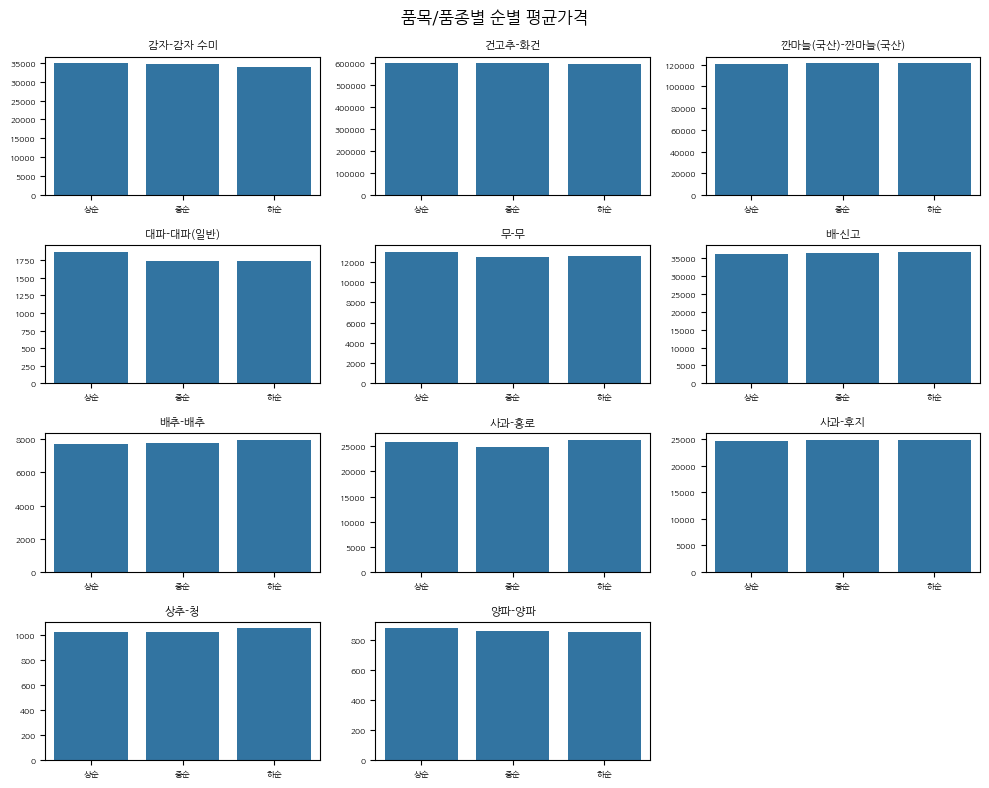

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

items = train_target[['품목명','품종명']].drop_duplicates().values

soon_order = ['상순', '중순', '하순']

fig, axes = plt.subplots(4, 3, figsize=(10, 8))

for i, (item, variety) in enumerate(items):
    ax = axes[i//3, i%3]

    df = train_target[
        (train_target['품목명'] == item) &
        (train_target['품종명'] == variety)
    ].copy()

    df['순'] = pd.Categorical(df['순'], categories=soon_order, ordered=True)
    soon_avg = df.groupby('순', as_index=False)['평균가격(원)'].mean()

    sns.barplot(data=soon_avg, x='순', y='평균가격(원)', ax=ax)
    ax.set_title(f"{item}-{variety}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', labelsize=6)

for j in range(len(items), 12):
    fig.delaxes(axes[j//3, j%3])

fig.suptitle("품목/품종별 순별 평균가격", fontsize=12)
plt.tight_layout()
plt.show()

미세하게 차이 존재

- 순_num (1,2,3) 피처 넣어봐도 좋을듯?

## 품목별 상관관계

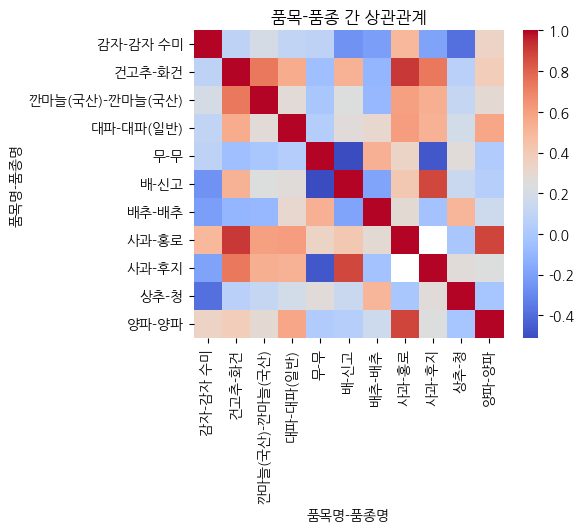

In [ ]:
pivot = train_target.pivot_table(
    index='time_order',
    columns=['품목명','품종명'],
    values='평균가격(원)'
)

corr = pivot.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, cmap='coolwarm')
plt.title("품목-품종 간 상관관계")
plt.show()

- 사과-배
- 양파-대파 -> 조미채소? 수요구조 비슷


--


- 건고추-사과 ???
- 배추-상추 낮음
  - 생산/유통 구조 다름 (김치..와 신선채소)

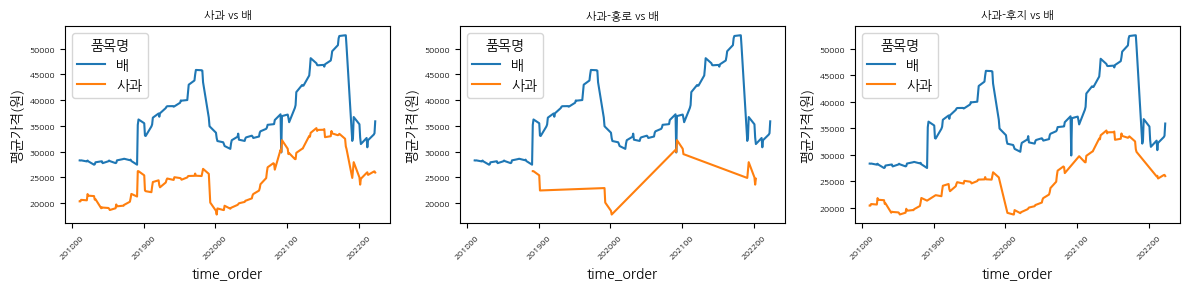

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(12, 3))ㄴ

# 1. 사과 전체 vs 배
df1 = train_target[train_target['품목명'].isin(['사과','배'])]
sns.lineplot(data=df1, x='time_order', y='평균가격(원)', hue='품목명', ax=axes[0], errorbar=None)
axes[0].set_title("사과 vs 배", fontsize=8)

# 2. 사과-홍로 vs 배
df2 = train_target[
    ((train_target['품목명']=='사과') & (train_target['품종명']=='홍로')) |
    (train_target['품목명']=='배')
]
sns.lineplot(data=df2, x='time_order', y='평균가격(원)', hue='품목명', ax=axes[1], errorbar=None)
axes[1].set_title("사과-홍로 vs 배", fontsize=8)

# 3. 사과-후지 vs 배
df3 = train_target[
    ((train_target['품목명']=='사과') & (train_target['품종명']=='후지')) |
    (train_target['품목명']=='배')
]
sns.lineplot(data=df3, x='time_order', y='평균가격(원)', hue='품목명', ax=axes[2], errorbar=None)
axes[2].set_title("사과-후지 vs 배", fontsize=8)

for ax in axes:
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

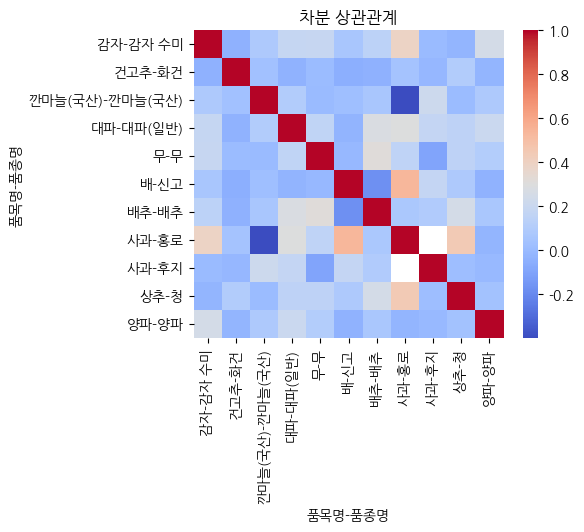

In [ ]:
pivot = train_target.pivot_table(
    index='time_order',
    columns=['품목명','품종명'],
    values='평균가격(원)'
)

diff_corr = pivot.diff().corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(diff_corr, cmap='coolwarm')
plt.title("차분 상관관계")
plt.show()

- diff(t) = price(t) - price(t-1)
- 변화량 비교

--

- 대부분의 상관 - 트렌드(증가/감소 여부) 영향 큼
- 차분 상관 결과
  - 사과(홍로)-배


[최종 피처 구성]
- 기존 피처들

1. lag 피처 (lag1/2/3 -> 최근 1개월(상순/중순/하순) 정보 사용)
2. diff 피처(lag1-lag2, lag2-lag3)
3. 계절성(month/sin_month/cos_month/순_num) -- 주기성 반영
4. 품목 간(사과-배) ex. 배_price_lag 피처
5. rolling (mean, std) -> 노이즈 완화
6. 원래 값인지 / 보간된 값인지 여부